In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

In [41]:
dt_errores = pd.read_parquet('..//resultados_prueba2.parquet')
dt_errores["cov"] = dt_errores["cov"].apply(lambda x: np.array(ast.literal_eval(x)))

In [42]:
print(dt_errores.sort_values('error',ascending=True).head(5))

top1p = (
    dt_errores
    .sort_values('error', ascending=True)
    .head( int(dt_errores.shape[0] * 0.01) )
)

top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    m_error=('error', 'mean'), sd_error = ('error', 'std'), n = ('error', 'count')
).sort_values('m_error', ascending=True)

       modelo covariables                                                cov  \
95582      D5          M2  [2.220135561416962, -0.4758868156039921, -0.94...   
185798     D5          M2  [2.093766189236983, -0.2996310111683185, 4.036...   
107222     D5          M1  [2.0033578864974855, -1.2828448902352008, 2.40...   
107223     D6          M1  [2.0033578864974855, -1.2828448902352008, 2.40...   
330536     D5          M1  [1.9618747222580408, -0.7278604562152355, -3.6...   

             phi     sigma    p_seco  p_transitorio  p_lluvioso     beta3  \
95582   0.597366  0.535778  0.586268       0.226944    0.559260  4.906975   
185798 -0.369893  0.510931  0.644210       0.197686    0.424286  5.343413   
107222 -0.298125  0.196038  0.623496       0.866581    0.265334  3.881519   
107223 -0.298125  0.196038  0.623496       0.866581    0.265334  3.881519   
330536  0.174864  0.177603  0.344541       0.456252    0.549327  3.463455   

             rho     error  
95582   0.969989  1.507973 

,modelo,covariables,m_error,sd_error,n
14,D5,M1,3.447140,0.758882,521
21,D6,M1,3.460500,0.751219,417
28,D7,M1,3.580939,0.613552,362
22,D6,M2,3.603146,0.665907,192
35,D8,M1,3.628499,0.603818,315
15,D5,M2,3.632768,0.694703,257
29,D7,M2,3.716013,0.573641,159
36,D8,M2,3.759837,0.552732,134
16,D5,M3,3.790005,0.599613,106
23,D6,M3,3.840700,0.538711,82


In [43]:
dfD5_M1 = top1p[(top1p.modelo =='D5') & (top1p.covariables =='M1')]
print(dfD5_M1.info())

dfD6_M1 = top1p[(top1p.modelo =='D6') & (top1p.covariables =='M1')]
print(dfD6_M1.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 521 entries, 107222 to 157412
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   modelo         521 non-null    object 
 1   covariables    521 non-null    object 
 2   cov            521 non-null    object 
 3   phi            521 non-null    float64
 4   sigma          521 non-null    float64
 5   p_seco         521 non-null    float64
 6   p_transitorio  521 non-null    float64
 7   p_lluvioso     521 non-null    float64
 8   beta3          521 non-null    float64
 9   rho            521 non-null    float64
 10  error          521 non-null    float64
dtypes: float64(8), object(3)
memory usage: 48.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Int64Index: 417 entries, 107223 to 301977
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   modelo         417 non-null    object 
 1   covaria

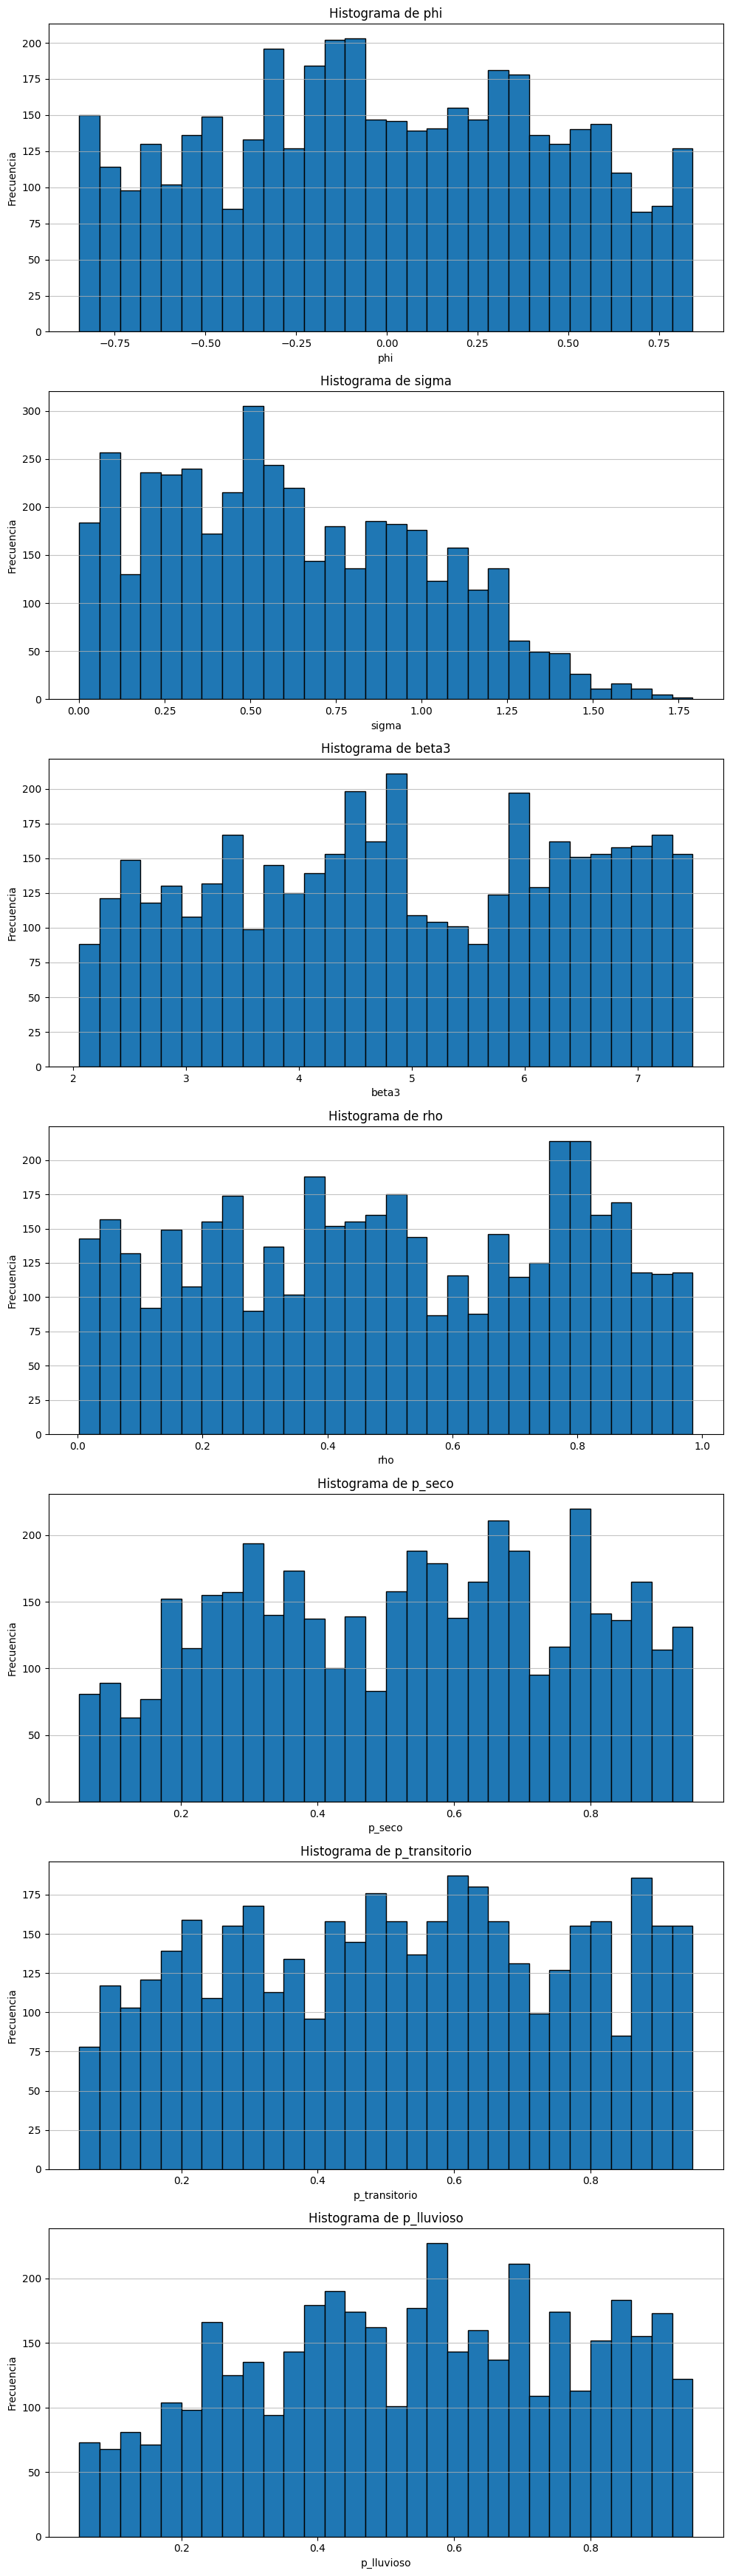

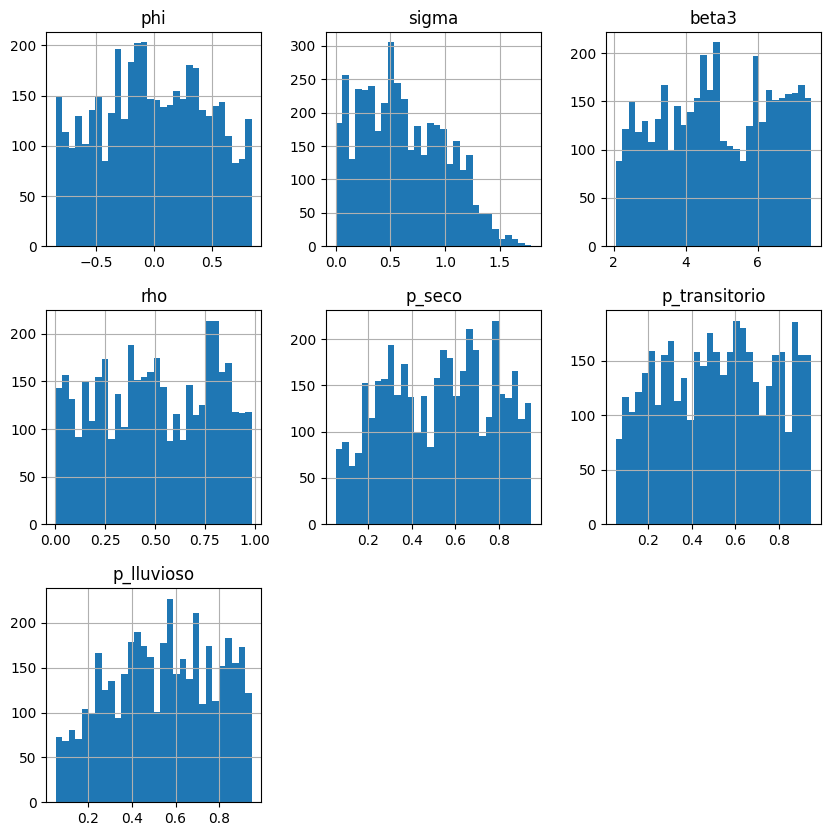

In [44]:
columnas_numericas = ['phi','sigma','beta3','rho','p_seco','p_transitorio','p_lluvioso']

fig, axs = plt.subplots(len(columnas_numericas), 1, figsize=(10, 5*len(columnas_numericas)))

for ax, col in zip(axs, columnas_numericas):
    
    if col in top1p.columns:
        ax.hist(top1p[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f'Histograma de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.75)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

top1p[columnas_numericas].hist(bins=30, figsize=(10,10))
plt.show()

In [45]:
revision_modelos = ['D5','D6']
revision_covariables = ['M1','M2']

subset = top1p[
    (top1p["modelo"].isin(revision_modelos)) &
    (top1p["covariables"].isin(revision_covariables))
]

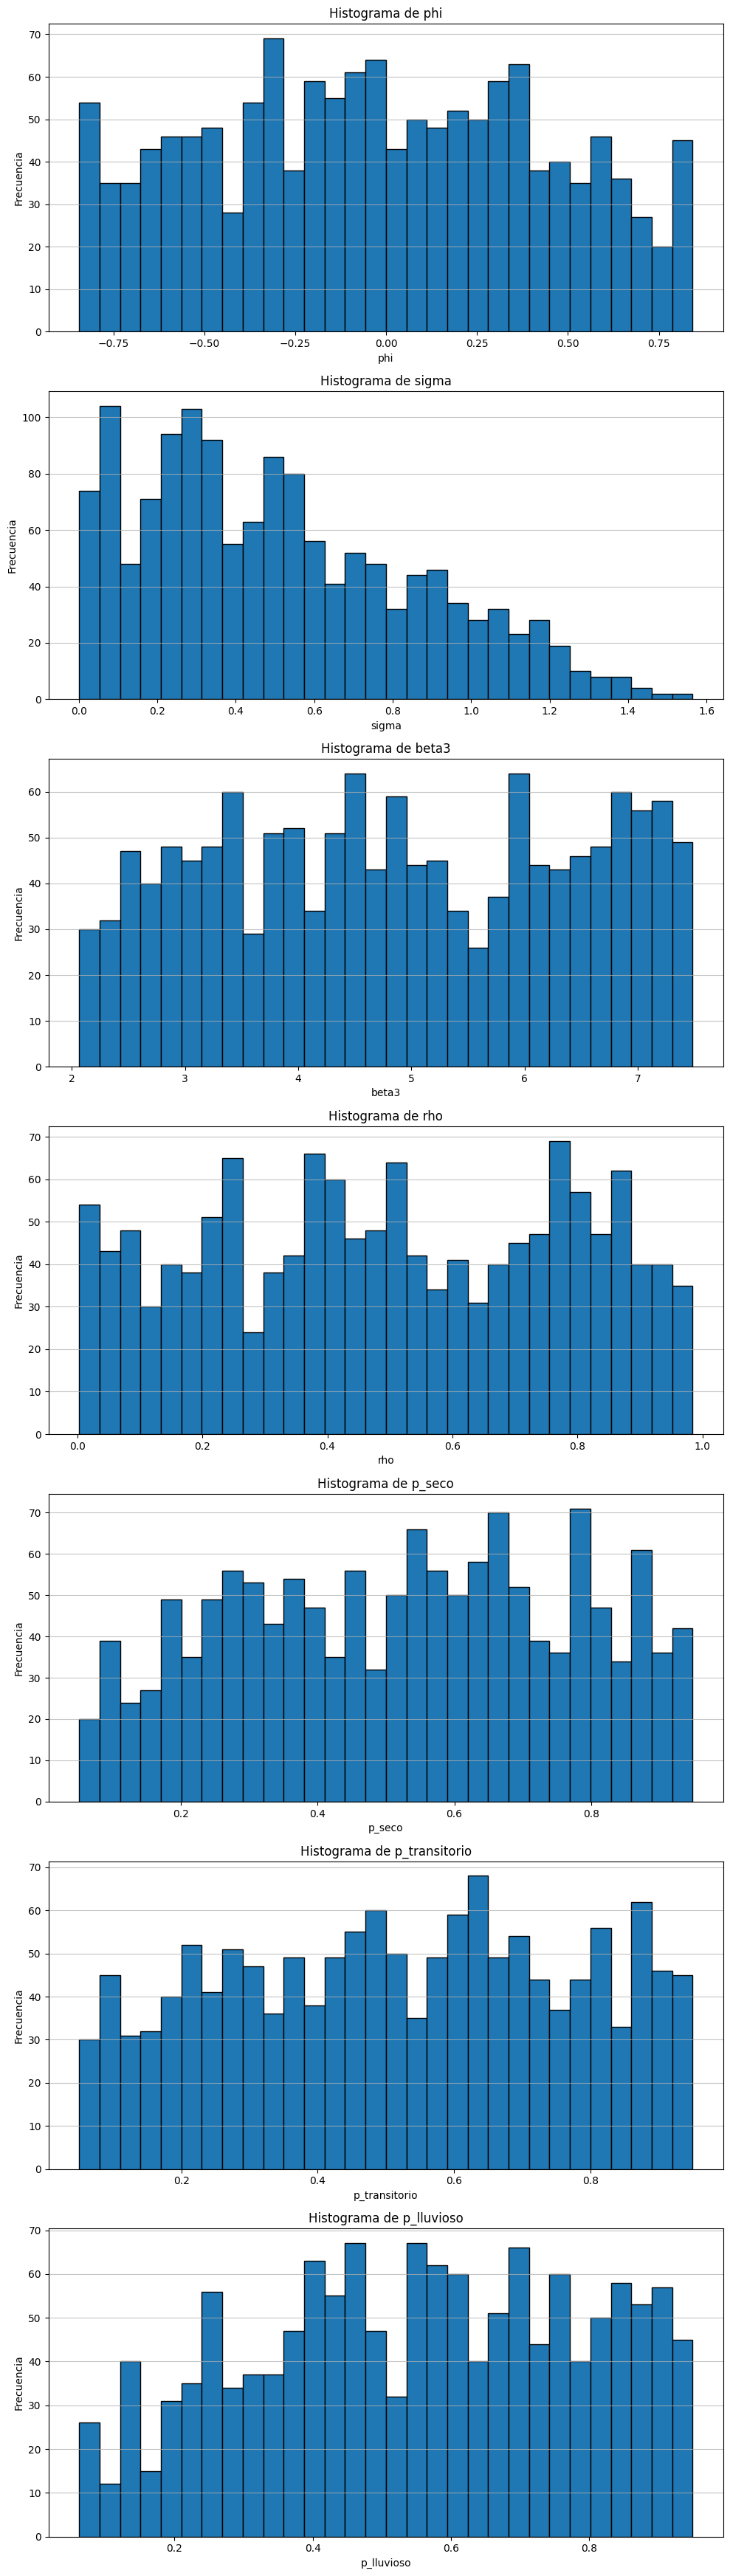

In [46]:
columnas_numericas = ['phi','sigma','beta3','rho','p_seco','p_transitorio','p_lluvioso']

fig, axs = plt.subplots(len(columnas_numericas), 1, figsize=(10, 5*len(columnas_numericas)))

for ax, col in zip(axs, columnas_numericas):

    if col in subset.columns:
        ax.hist(subset[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f'Histograma de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.75)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

In [47]:
covariables_espaciales = np.vstack(dt_errores["cov"])
columnas_espaciales = ["G0", "G1", "G2", "G3", "G12", "G22", "G32"]
dt_cov = pd.DataFrame(covariables_espaciales, columns = columnas_espaciales)
dt_cov = pd.concat(
    [dt_errores[["modelo", "covariables"]].reset_index(drop=True),
     dt_cov,
     dt_errores[["error"]].reset_index(drop=True)
     ],
    axis=1
)

In [48]:
top1p = (
    dt_cov
    .sort_values('error', ascending=True)
    .head( int(dt_cov.shape[0] * 0.01) )
)

top1p.groupby(['modelo', 'covariables'], as_index=False).agg(
    m_error=('error', 'mean'), sd_error = ('error', 'std'), n = ('error', 'count')
).sort_values('m_error', ascending=True)

,modelo,covariables,m_error,sd_error,n
14,D5,M1,3.447140,0.758882,521
21,D6,M1,3.460500,0.751219,417
28,D7,M1,3.580939,0.613552,362
22,D6,M2,3.603146,0.665907,192
35,D8,M1,3.628499,0.603818,315
15,D5,M2,3.632768,0.694703,257
29,D7,M2,3.716013,0.573641,159
36,D8,M2,3.759837,0.552732,134
16,D5,M3,3.790005,0.599613,106
23,D6,M3,3.840700,0.538711,82


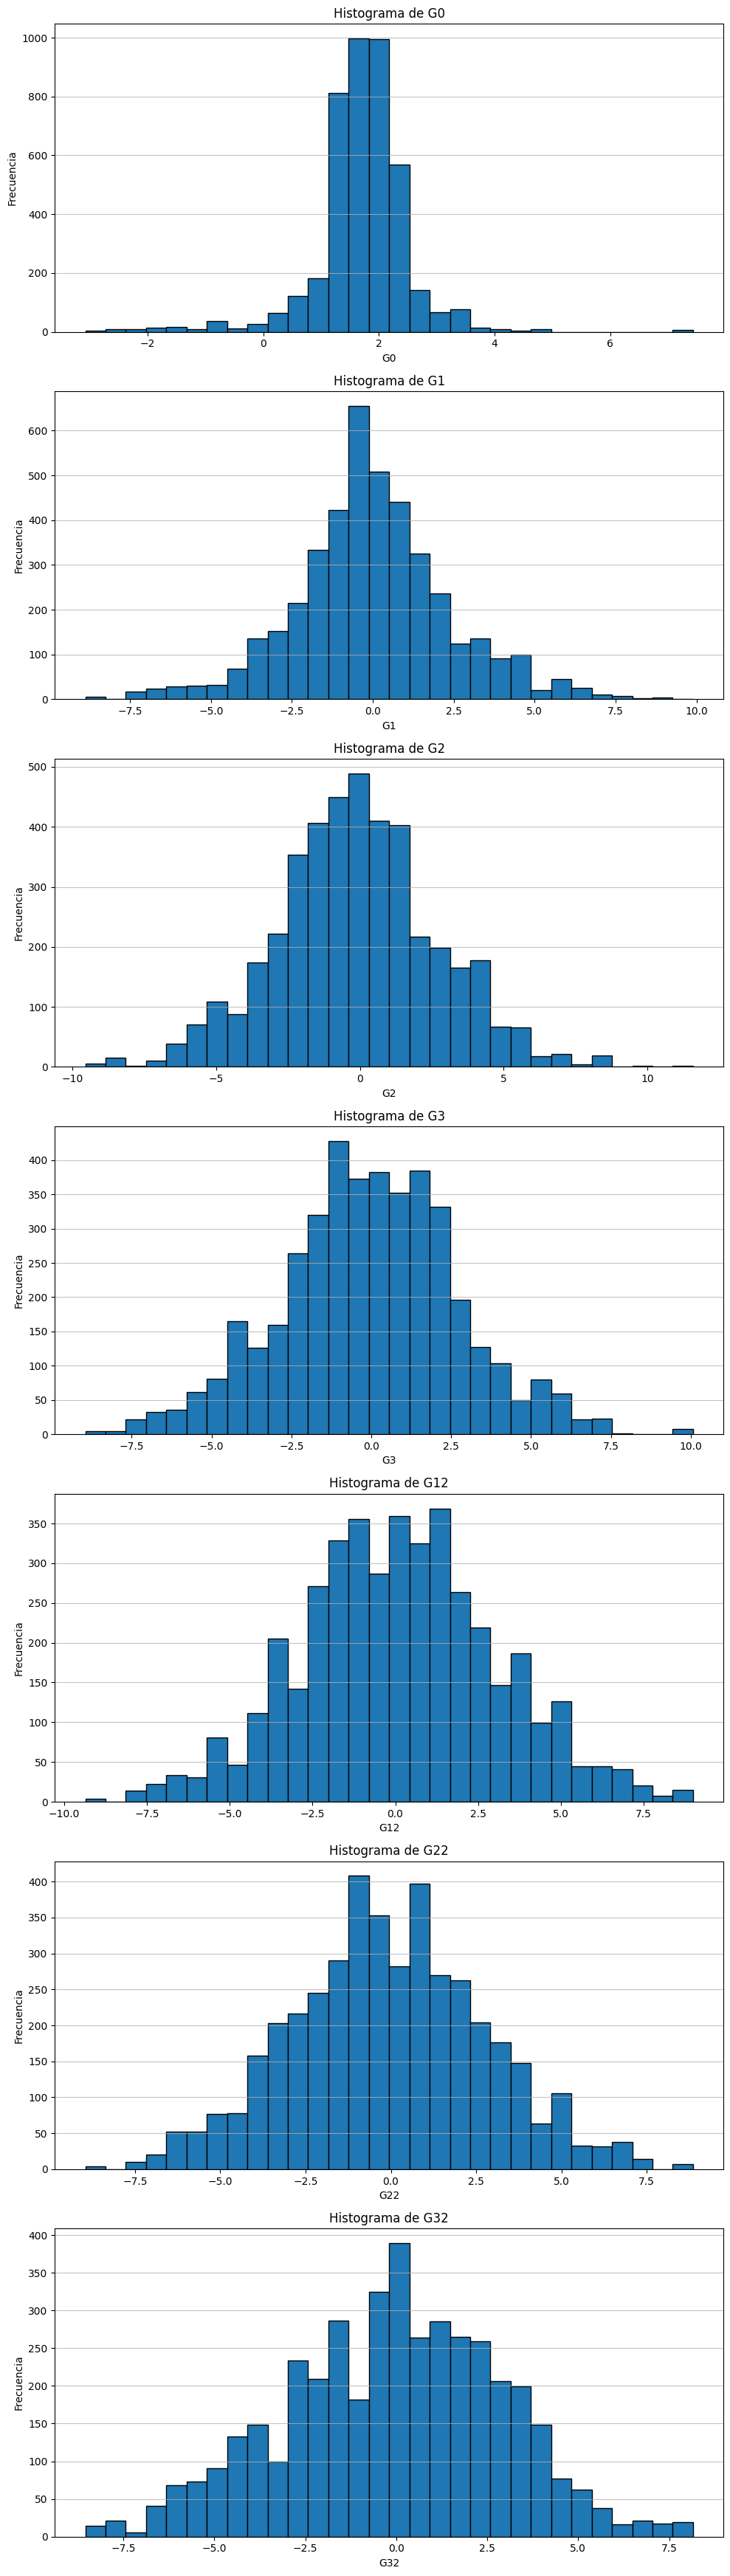

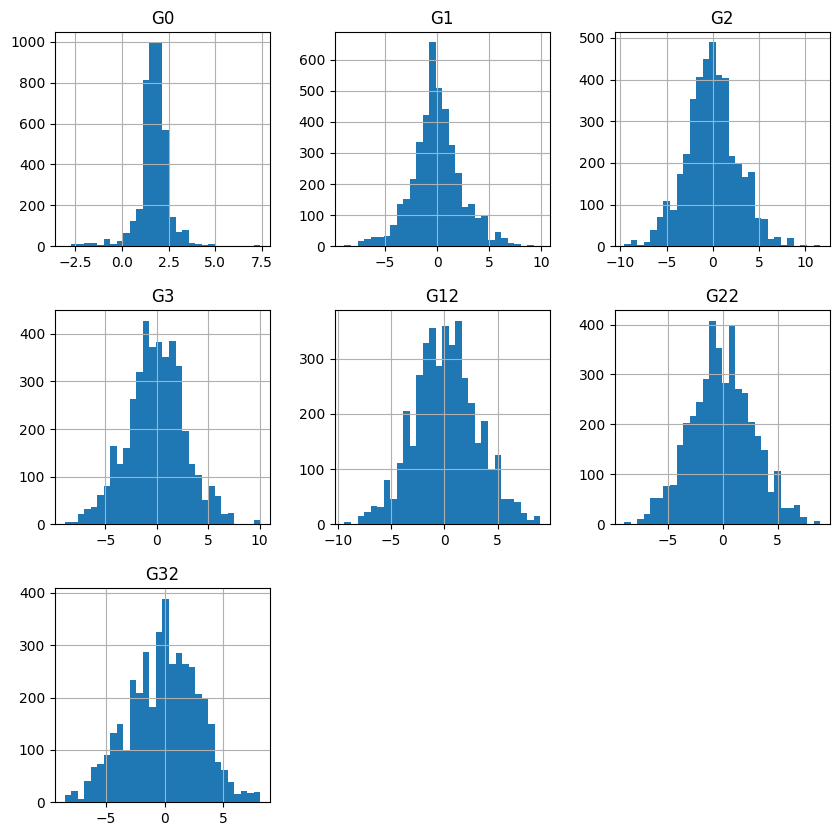

In [49]:
fig, axs = plt.subplots(len(columnas_espaciales), 1, figsize=(10, 5*len(columnas_espaciales)))

for ax, col in zip(axs, columnas_espaciales):
    
    if col in top1p.columns:
        ax.hist(top1p[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f'Histograma de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.75)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

top1p[columnas_espaciales].hist(bins=30, figsize=(10,10))
plt.show()

In [38]:
revision_modelos = ['D5','D6']
revision_covariables = ['M1','M2']

subset = top1p[
    (top1p["modelo"].isin(revision_modelos)) &
    (top1p["covariables"].isin(revision_covariables))
]

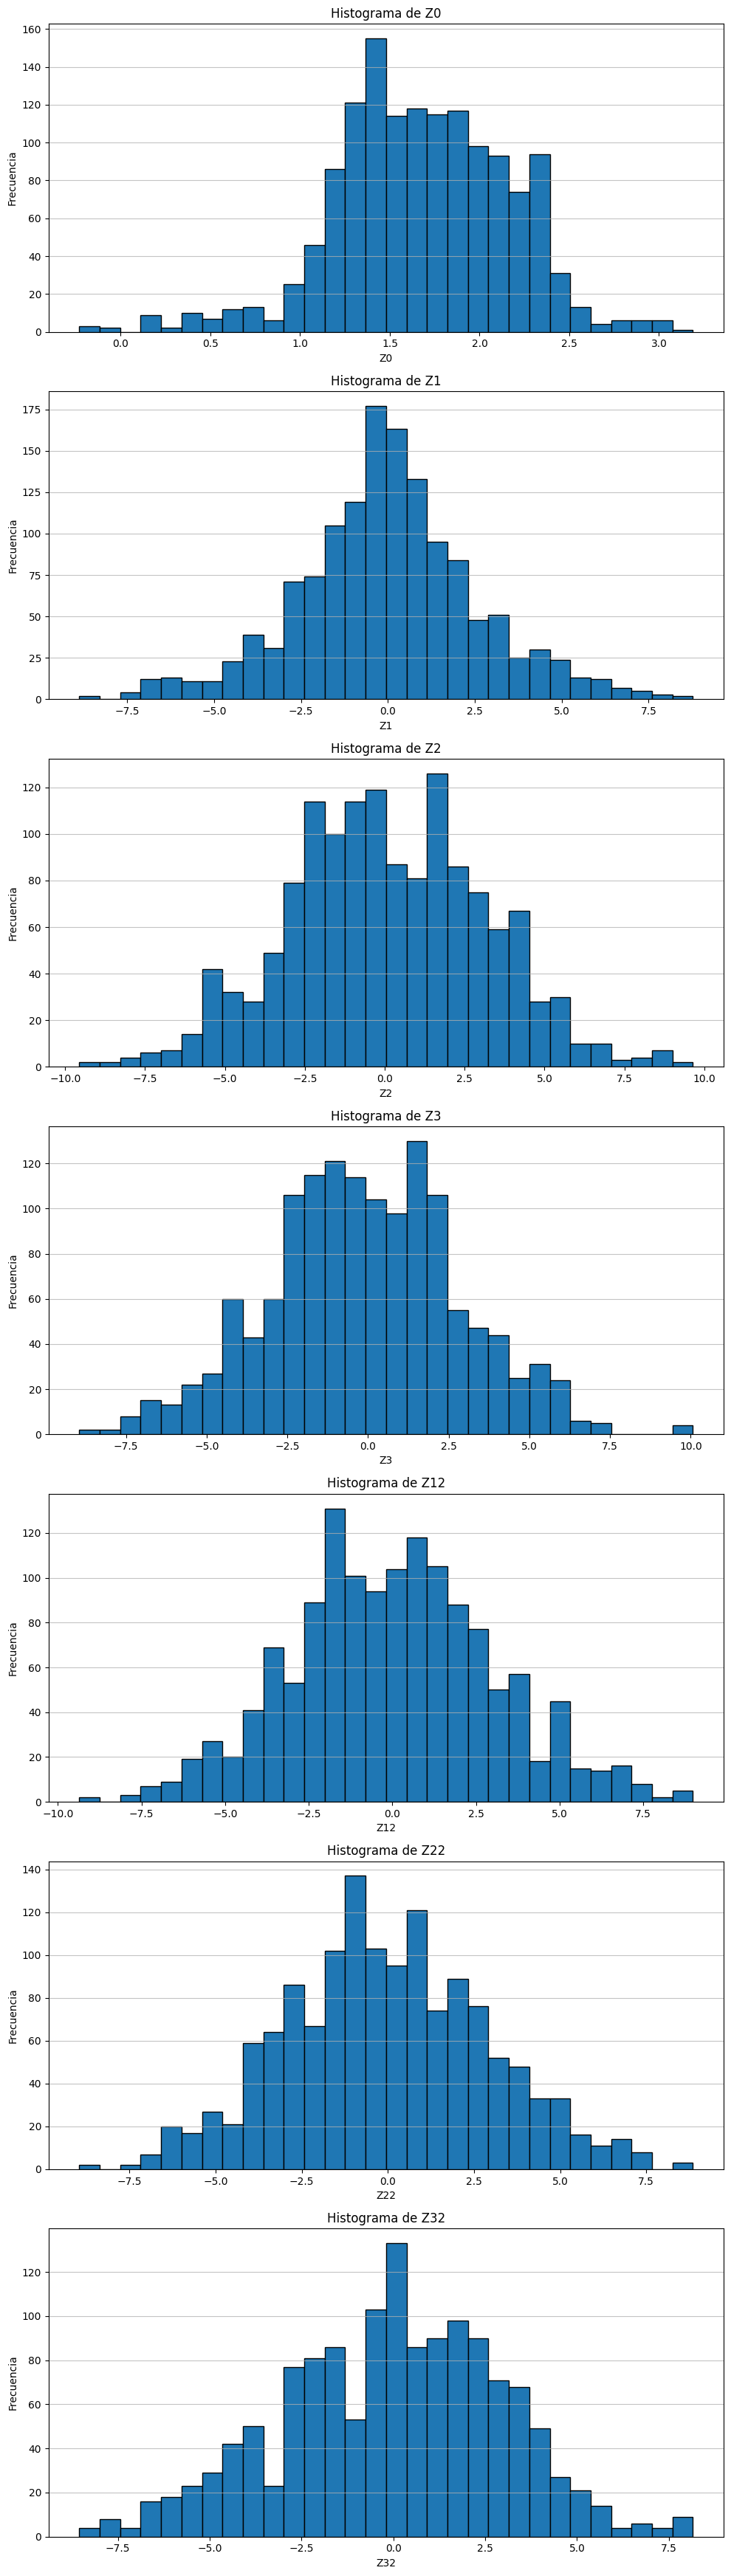

In [39]:
fig, axs = plt.subplots(len(columnas_espaciales), 1, figsize=(10, 5*len(columnas_espaciales)))

for ax, col in zip(axs, columnas_espaciales):

    if col in subset.columns:
        ax.hist(subset[col].dropna(), bins=30, edgecolor='black')
        ax.set_title(f'Histograma de {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frecuencia')
        ax.grid(axis='y', alpha=0.75)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()